In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI()

In [4]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [5]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

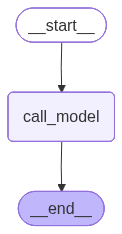

In [6]:
graph = builder.compile()
graph

In [7]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Nitish."}]})

{'messages': [HumanMessage(content='Hi! My name is Nitish.', additional_kwargs={}, response_metadata={}, id='80cd7293-1fa7-4c86-98ca-dc77a20233ca'),
  AIMessage(content='Hello Nitish! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 15, 'total_tokens': 26, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DTnU8QubLGi2X3TvzMqVPEGB12r8E', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d817f-6484-7941-b66a-595b8ea7731e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 11, 'total_tokens': 26, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_t

In [8]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]})

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='500c4f62-f6d9-423e-8ee0-cdc5e3174de5'),
  AIMessage(content="I'm sorry, I do not know your name.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 12, 'total_tokens': 23, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DTnUE7vC0dW7lOBE4ybEwfkIWWD8N', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d817f-7f91-7373-a02f-512d0f01062a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 11, 'total_tokens': 23, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details

In [9]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [10]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [11]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [12]:
config = {"configurable": {"thread_id": "thread-1"}}
config2 = {"configurable": {"thread_id": "thread-2"}}

In [13]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Nitish."}]}, config)

{'messages': [HumanMessage(content='Hi! My name is Nitish.', additional_kwargs={}, response_metadata={}, id='0f9864ba-390e-4926-9103-a2986a522843'),
  AIMessage(content='Hello Nitish! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 15, 'total_tokens': 26, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DTnV0TV30tENxGindVkXg0GvJtw6M', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d8180-3792-7fb2-9ad8-29467eb0035c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 11, 'total_tokens': 26, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_t

In [17]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]}, config2)

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='2a0130b2-4df7-4b1a-a8f3-b22ee41766a2'),
  AIMessage(content="I'm sorry, I do not have the ability to determine your name. Can you please tell me what it is?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 12, 'total_tokens': 36, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DTnYbYtJu3Us6BdF6fCD4xFDS5VBf', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d8183-9f67-72c2-a7e6-344077e99f05-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 24, 'total_tokens': 36, 'input_token_de

In [18]:
snap = graph.get_state(config2)
vals = snap.values
for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content)

- HumanMessage : What is my name?
- AIMessage : I'm sorry, I do not have the ability to determine your name. Can you please tell me what it is?


In [16]:
snap

StateSnapshot(values={'messages': [HumanMessage(content='Hi! My name is Nitish.', additional_kwargs={}, response_metadata={}, id='0f9864ba-390e-4926-9103-a2986a522843'), AIMessage(content='Hello Nitish! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 15, 'total_tokens': 26, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DTnV0TV30tENxGindVkXg0GvJtw6M', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d8180-3792-7fb2-9ad8-29467eb0035c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 11, 'total_tokens': 26, 'input_token_details': {'audio': 0, 'cache_r